# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**: Dataset Titanic diperoleh dari [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic). Dataset ini merupakan salah satu dataset publik paling populer.

2. **Deskripsi Dataset**: Berisi informasi penumpang kapal Titanic untuk memprediksi apakah seorang penumpang selamat (`Survived=1`) atau tidak (`Survived=0`).

3. **Fitur Dataset**:
   - `Survived` : Target — 0 = Tidak Selamat, 1 = Selamat
   - `Pclass`   : Kelas tiket (1=1st, 2=2nd, 3=3rd)
   - `Sex`      : Jenis kelamin
   - `Age`      : Usia penumpang
   - `SibSp`    : Jumlah saudara/pasangan di kapal
   - `Parch`    : Jumlah orang tua/anak di kapal
   - `Fare`     : Tarif tiket
   - `Cabin`    : Nomor kabin
   - `Embarked` : Pelabuhan keberangkatan (C, Q, S)

4. **Tujuan**: Klasifikasi biner — memprediksi survival penumpang Titanic.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Library berhasil diimport!')
print(f'Pandas : {pd.__version__}')
print(f'NumPy  : {np.__version__}')

Library berhasil diimport!
Pandas : 2.3.3
NumPy  : 2.4.4


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset dari folder raw
df = pd.read_csv('../titanic_raw/titanic.csv')

print('=== INFORMASI AWAL DATASET ===')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')
print(f'Kolom        : {list(df.columns)}')
print()
df.head()

=== INFORMASI AWAL DATASET ===
Jumlah baris : 200
Jumlah kolom : 12
Kolom        : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# 4.1 Informasi Umum
print('=== INFO TIPE DATA ===')
df.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  200 non-null    int64  
 1   Survived     200 non-null    int64  
 2   Pclass       200 non-null    int64  
 3   Name         200 non-null    object 
 4   Sex          200 non-null    object 
 5   Age          170 non-null    float64
 6   SibSp        200 non-null    int64  
 7   Parch        200 non-null    int64  
 8   Ticket       200 non-null    object 
 9   Fare         200 non-null    float64
 10  Cabin        80 non-null     object 
 11  Embarked     200 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.9+ KB

=== STATISTIK DESKRIPTIF ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,200.000000,200.000000,200.000000,170.000000,200.000000,200.000000,200.000000
mean,100.500000,0.470000,2.050000,37.588235,0.725000,0.270000,52.149005
std,57.879185,0.500352,0.812899,19.561945,0.862027,0.456224,27.569970
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,5.160700
25%,50.750000,0.000000,1.000000,21.250000,0.000000,0.000000,29.671975
50%,100.500000,0.000000,2.000000,39.000000,0.000000,0.000000,52.372200
75%,150.250000,1.000000,3.000000,54.750000,2.000000,1.000000,77.452125
max,200.000000,1.000000,3.000000,70.000000,3.000000,2.000000,99.869700


       Missing  Pct (%)
Cabin      120     60.0
Age         30     15.0


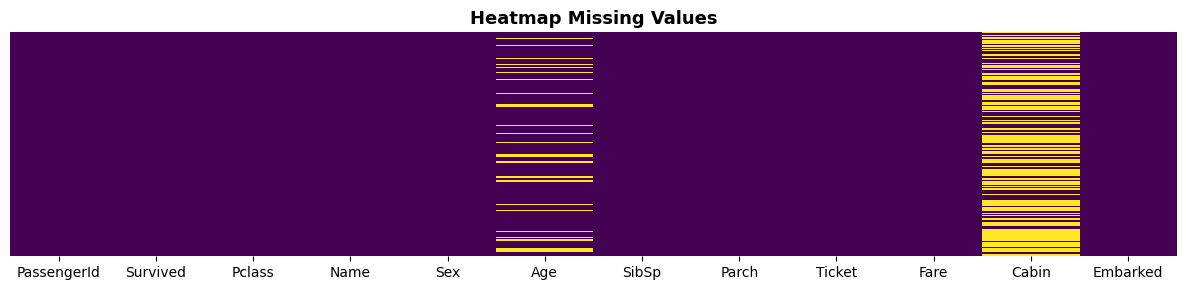

In [4]:
# 4.2 Cek Missing Values
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'Missing': missing, 'Pct (%)': pct})
print(mv[mv['Missing'] > 0].sort_values('Missing', ascending=False))

plt.figure(figsize=(12, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap Missing Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

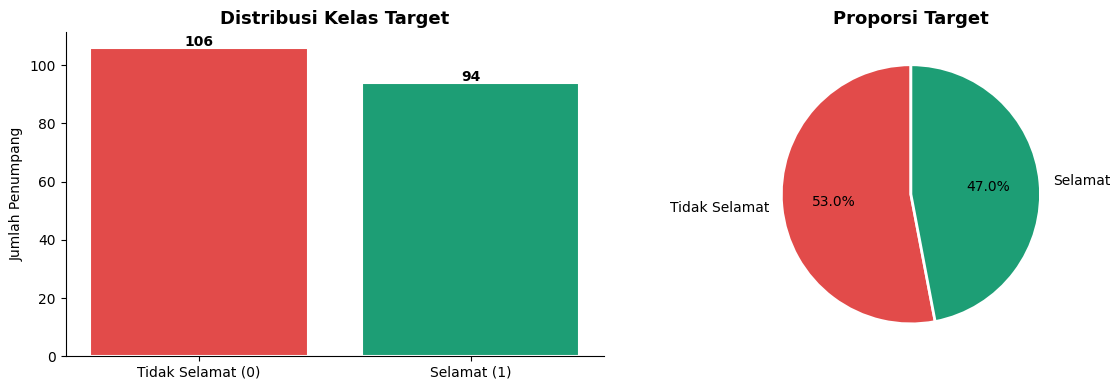

In [5]:
# 4.3 Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Survived'].value_counts()

axes[0].bar(['Tidak Selamat (0)', 'Selamat (1)'], counts.values,
            color=['#E24B4A', '#1D9E75'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Penumpang')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Tidak Selamat', 'Selamat'],
            colors=['#E24B4A', '#1D9E75'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

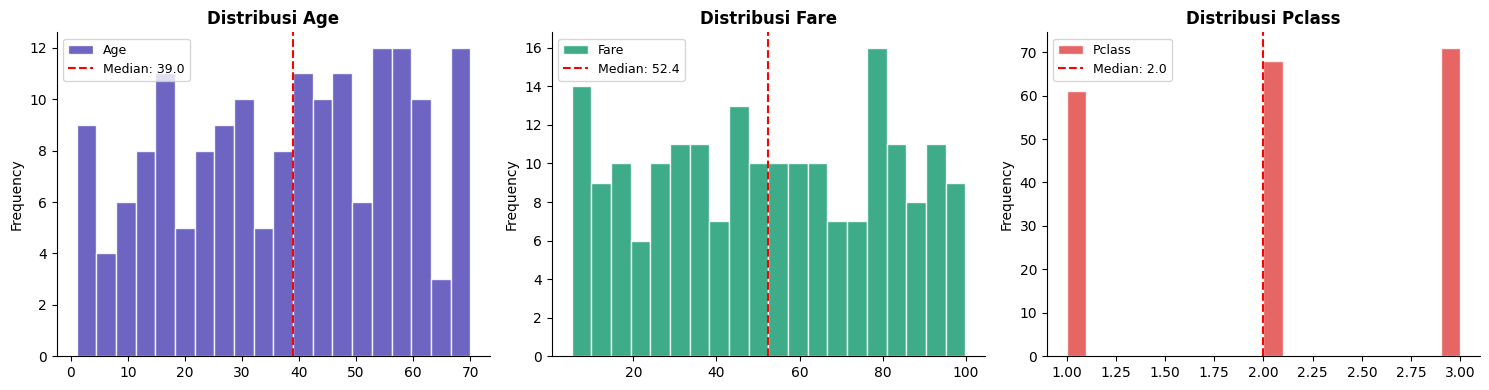

In [6]:
# 4.4 Distribusi Fitur Numerik
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols_colors = [('Age', '#534AB7'), ('Fare', '#1D9E75'), ('Pclass', '#E24B4A')]

for ax, (col, color) in zip(axes, cols_colors):
    df[col].dropna().plot(kind='hist', ax=ax, bins=20, color=color,
                          edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

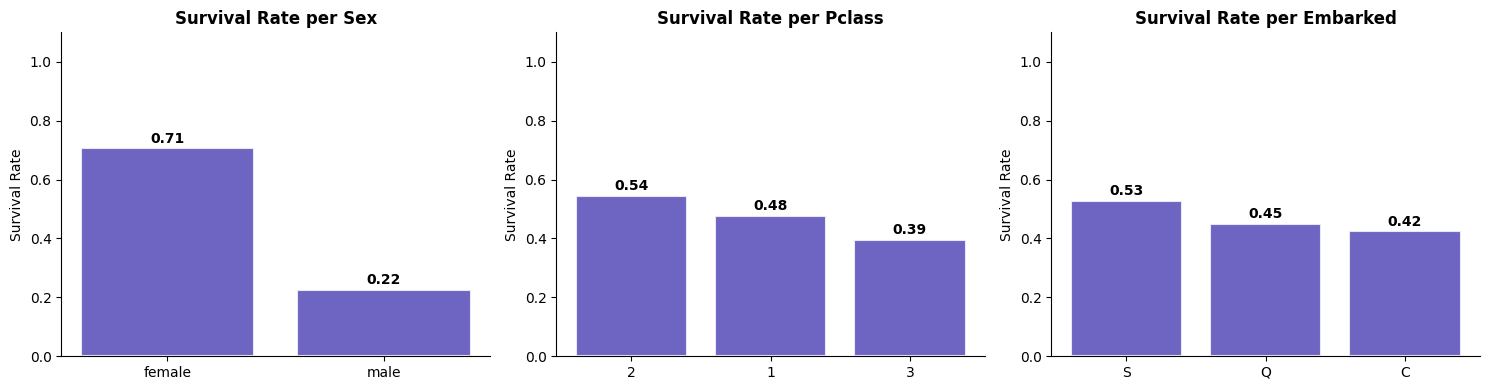

In [7]:
# 4.5 Survival Rate per Kategori
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    sr = df.groupby(col)['Survived'].mean().sort_values(ascending=False)
    bars = ax.bar(sr.index.astype(str), sr.values, color='#534AB7',
                  edgecolor='white', linewidth=1.5, alpha=0.85)
    ax.set_title(f'Survival Rate per {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, sr.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

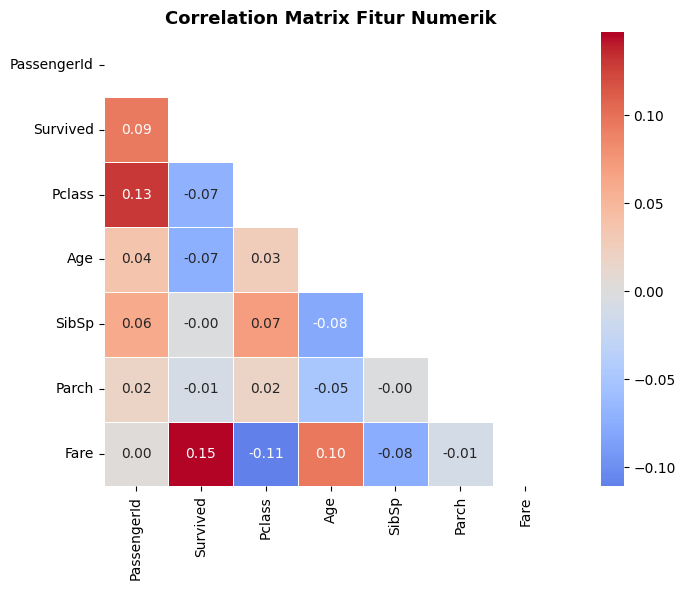

Korelasi dengan Survived:
Fare           0.147236
PassengerId    0.094221
SibSp         -0.001748
Parch         -0.008365
Pclass        -0.070422
Age           -0.073489
Name: Survived, dtype: float64


In [8]:
# 4.6 Correlation Matrix
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Matrix Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi dengan Survived:')
print(corr['Survived'].sort_values(ascending=False)[1:])

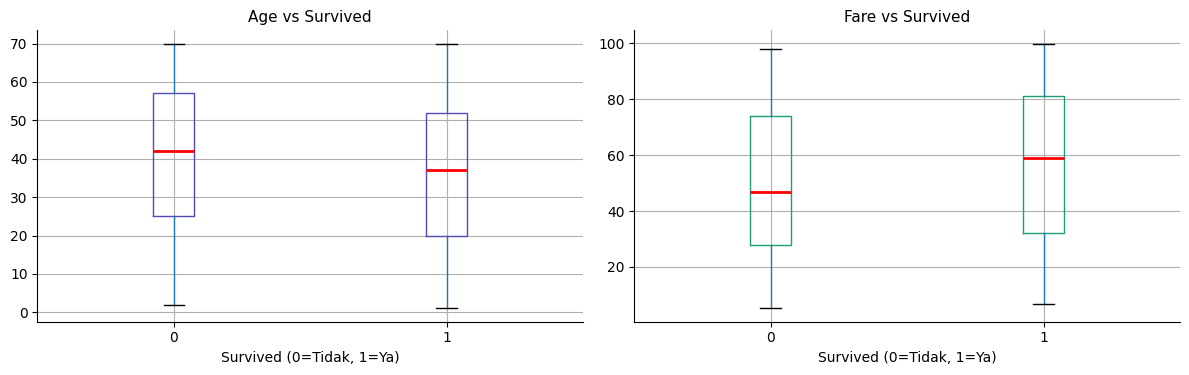

In [9]:
# 4.7 Boxplot Age dan Fare vs Survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ['Age', 'Fare'], ['#534AB7', '#1D9E75']):
    df.boxplot(column=col, by='Survived', ax=ax,
               boxprops=dict(color=color),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} vs Survived', fontsize=11)
    ax.set_xlabel('Survived (0=Tidak, 1=Ya)')
    plt.suptitle('')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# 5.1 Salin DataFrame
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')
print('Missing values:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Shape awal: (200, 12)
Missing values:
Age       30
Cabin    120
dtype: int64


In [11]:
# 5.2 Handle Missing Values
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())
df_clean = df_clean.drop(columns=['Cabin'], errors='ignore')

print('Setelah handle missing values:')
print(f'  Missing tersisa : {df_clean.isnull().sum().sum()}')
print(f'  Kolom Cabin dihapus (missing terlalu banyak)')

Setelah handle missing values:
  Missing tersisa : 0
  Kolom Cabin dihapus (missing terlalu banyak)


In [12]:
# 5.3 Hapus Data Duplikat
dup = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f'Duplikat ditemukan : {dup}')
print(f'Shape setelah drop : {df_clean.shape}')

Duplikat ditemukan : 0
Shape setelah drop : (200, 11)


In [13]:
# 5.4 Drop Kolom Tidak Relevan
cols_drop = ['PassengerId', 'Name', 'Ticket']
df_clean = df_clean.drop(columns=cols_drop, errors='ignore')
print(f'Kolom dihapus : {cols_drop}')
print(f'Kolom tersisa : {list(df_clean.columns)}')

Kolom dihapus : ['PassengerId', 'Name', 'Ticket']
Kolom tersisa : ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [14]:
# 5.5 Encoding Kolom Kategorikal
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])
print(f'Sex encoding     : female=0, male=1')
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'].astype(str))
print(f'Embarked encoding: C=0, Q=1, S=2')
print()
df_clean.head()

Sex encoding     : female=0, male=1
Embarked encoding: C=0, Q=1, S=2



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [15]:
# 5.6 Feature Engineering
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
print('Fitur baru ditambahkan: FamilySize, IsAlone')
print(df_clean[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(6))

Fitur baru ditambahkan: FamilySize, IsAlone
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1


In [16]:
# 5.7 Deteksi dan Penanganan Outlier (IQR)
col = 'Fare'
Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
before = len(df_clean)
df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
print(f'Outlier Fare dihapus : {before - len(df_clean)} baris')
print(f'Range valid Fare     : [{lower:.2f}, {upper:.2f}]')
print(f'Shape setelah        : {df_clean.shape}')

Outlier Fare dihapus : 0 baris
Range valid Fare     : [-42.00, 149.12]
Shape setelah        : (200, 10)


In [17]:
# 5.8 Normalisasi / Standarisasi Fitur (StandardScaler)
scaler = StandardScaler()
cols_scale = ['Age', 'Fare', 'FamilySize']
df_clean[cols_scale] = scaler.fit_transform(df_clean[cols_scale])

print('Statistik setelah StandardScaler:')
df_clean[cols_scale].describe().round(3)

Statistik setelah StandardScaler:


,Age,Fare,FamilySize
count,200.000,200.000,200.000
mean,0.000,0.000,-0.000
std,1.003,1.003,1.003
min,-2.046,-1.709,-1.024
25%,-0.712,-0.817,-1.024
50%,0.067,0.008,0.005
75%,0.789,0.920,1.034
max,1.790,1.735,3.091


In [18]:
# 5.9 Train/Test Split & Simpan Dataset
import os

X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train : {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test : {y_test.shape}')
print()
print(f'Distribusi y_train:')
print(y_train.value_counts())

out_dir = 'titanic_preprocessing'
os.makedirs(out_dir, exist_ok=True)
X_train.to_csv(f'{out_dir}/X_train.csv', index=False)
X_test.to_csv(f'{out_dir}/X_test.csv',   index=False)
y_train.to_csv(f'{out_dir}/y_train.csv', index=False)
y_test.to_csv(f'{out_dir}/y_test.csv',   index=False)
df_clean.to_csv(f'{out_dir}/titanic_preprocessing.csv', index=False)

print(f'File disimpan di: {out_dir}/')

X_train : (160, 9)  |  y_train: (160,)
X_test  : (40, 9)   |  y_test : (40,)

Distribusi y_train:
Survived
0    85
1    75
Name: count, dtype: int64
File disimpan di: /home/claude/preprocessing/titanic_preprocessing/


In [19]:
# 5.10 Ringkasan Preprocessing
print('=' * 50)
print('  RINGKASAN PREPROCESSING')
print('=' * 50)
print(f'Shape awal          : {df.shape}')
print(f'Shape akhir         : {df_clean.shape}')
print(f'Fitur model         : {list(X_train.columns)}')
print(f'Train set           : {X_train.shape[0]} rows')
print(f'Test set            : {X_test.shape[0]} rows')
print()
steps = [
    'Handle missing values (Age & Fare median, Embarked modus, drop Cabin)',
    'Hapus duplikat',
    'Drop kolom tidak relevan (PassengerId, Name, Ticket)',
    'Label Encoding (Sex, Embarked)',
    'Feature Engineering (FamilySize, IsAlone)',
    'Remove outlier Fare dengan IQR',
    'StandardScaler (Age, Fare, FamilySize)',
    'Train/Test split 80:20 dengan stratify',
]
for i, s in enumerate(steps, 1):
    print(f'  {i}. {s}')
print('=' * 50)
print('Dataset siap untuk pelatihan model!')

  RINGKASAN PREPROCESSING
Shape awal          : (200, 12)
Shape akhir         : (200, 10)
Fitur model         : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
Train set           : 160 rows
Test set            : 40 rows

  1. Handle missing values (Age & Fare median, Embarked modus, drop Cabin)
  2. Hapus duplikat
  3. Drop kolom tidak relevan (PassengerId, Name, Ticket)
  4. Label Encoding (Sex, Embarked)
  5. Feature Engineering (FamilySize, IsAlone)
  6. Remove outlier Fare dengan IQR
  7. StandardScaler (Age, Fare, FamilySize)
  8. Train/Test split 80:20 dengan stratify
Dataset siap untuk pelatihan model!
